In [1]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Custom functions (assumed in your local directory)
from fix_grid import fix_grid 
from useful_calculations import weighted_means

In [2]:
pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'
ds=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/mean_std_control_noice.nc', chunks='auto')
ds_cc=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/mean_std_1PctTo2X_noice.nc', chunks='auto')
jin=xr.open_dataset('GOBAI-O2-v2.3-Flux-Adjusted.nc')
fay=xr.open_dataset('SeaFlux_v2021.04_fgco2_all_winds_products.nc')
grid=xr.open_dataset(pathf+'ocean_grid.nc')

In [3]:
ds_1=ds.rename({'yt_ocean': 'lat', 'xt_ocean': 'lon'}).interp_like(fay)
ds_2=ds.rename({'yt_ocean': 'lat', 'xt_ocean': 'lon'}).interp_like(jin)
fay_all_=fay.fgco2.mean(dim=['time'])*-1
jin_all_=jin.fgo2_member.mean(dim='time')*-60*60*24*365
fay_all=fay_all_.mean(dim=['wind', 'product'])
fay_std_member=fay_all_.mean('lon').std(dim=['wind', 'product'])
jin_all=jin_all_.mean(dim=['wind', 'method'])
jin_std_member=jin_all_.mean('lon').std(dim=['wind', 'method'])

In [4]:
weight=grid.area_t.fillna(0)

In [5]:
co2_wm=ds.dic_stf_mean.weighted(weight).mean()
o2_wm=ds.o2_stf_mean.weighted(weight).mean()

In [6]:
co2_wm.values

array(-0.12380219, dtype=float32)

In [7]:
o2_wm.values

array(-0.4336123, dtype=float32)

In [6]:
diff_sq_co2 = (ds.dic_stf_mean - co2_wm)**2
diff_sq_o2 = (ds.o2_stf_mean - o2_wm)**2

In [7]:
co2_wm_variance = diff_sq_co2.weighted(weight).mean(dim=['xt_ocean', 'yt_ocean'])
o2_wm_variance = diff_sq_o2.weighted(weight).mean(dim=['xt_ocean', 'yt_ocean'])

In [8]:
global_std_co2 = np.sqrt(co2_wm_variance)
global_std_o2 = np.sqrt(o2_wm_variance)

In [11]:
print(global_std_co2.values,
global_std_o2.values )

1.7955446 4.770254


# Version 1 (std of zonal mean)

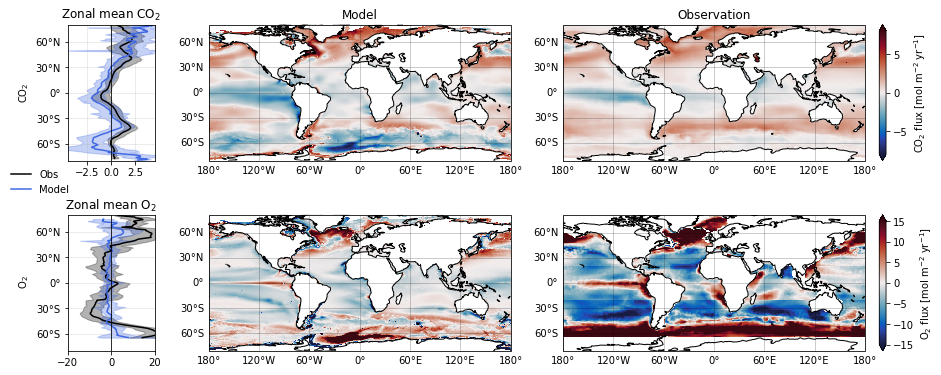

In [250]:
dic_zonal=ds_1.dic_stf_mean.mean(dim='lon')
o2_zonal=ds_2.o2_stf_mean.mean(dim='lon')

dic_zonal_std=ds_1.dic_stf_mean.std(dim='lon')
o2_zonal_std=ds_2.o2_stf_mean.std(dim='lon')

lat_true_1 = ds_1.geolat_t.where(ds_1.geolat_t<=90).mean(dim='lon')
dic_zonal_new = dic_zonal.assign_coords(lat=lat_true_1)
dic_zonal_std_new=dic_zonal_std.assign_coords(lat=lat_true_1)

lat_true_2=ds_2.geolat_t.where(ds_2.geolat_t<=90).mean(dim='lon')
o2_zonal_new = o2_zonal.assign_coords(lat=lat_true_2)
o2_zonal_std_new=o2_zonal_std.assign_coords(lat=lat_true_2)


fig = plt.figure(figsize=(15,6), layout='compressed')

gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 4, 4],   # small left column
    wspace=0.1,
    hspace=0.4
)

# --- Left column (zonal means) ---
ax_zm1 = fig.add_subplot(gs[0, 0])
ax_zm2 = fig.add_subplot(gs[1, 0])

# --- Maps ---
ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([-180, 180, -81.108635, 81.108635],
                  crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1,
                      color='black',
                      alpha=0.2)
    gl.xlabels_top = False
    gl.ylabels_left = True
    gl.ylabels_right= False

    ax.coastlines()

# Row 1 (DIC flux)
im1 = ds.dic_stf_mean.plot(
    ax=ax1,
    x='geolon_t',
    y='geolat_t',
    vmin=-8, vmax=8,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

im2 = fay_all.plot(
    ax=ax2,
    vmin=-8, vmax=8,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# Row 2 (O2 flux)
im3 = ds.o2_stf_mean.plot(
    ax=ax3,
    x='geolon_t',
    y='geolat_t',
    vmin=-15, vmax=15,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

im4 =jin_all.plot(
    ax=ax4,
    vmin=-15, vmax=15,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# --------------------------------------------------
# ZONAL MEANS
# --------------------------------------------------

# Compute zonal means (adjust dim names if needed)
fay_zm = fay_all.mean('lon')
jin_zm = jin_all.mean('lon')
fay_std = fay_all.std('lon')
jin_std = jin_all.std('lon')


# Plot zonal means
ax_zm1.plot(fay_zm, fay_zm.lat, c='k')
ax_zm1.fill_betweenx(fay_zm.lat,
                 fay_zm - fay_std,
                 fay_zm + fay_std,
                 alpha=0.3, color='k')

ax_zm2.plot(jin_zm, jin_zm.lat, c='k', label='Obs')
ax_zm2.fill_betweenx(jin_zm.lat,
                 jin_zm - jin_std,
                 jin_zm + jin_std,
                 alpha=0.3, color='k')

ax_zm1.plot(dic_zonal_new, dic_zonal_new.lat, c='royalblue')
ax_zm1.fill_betweenx(dic_zonal_std_new.lat,
                 dic_zonal_new - dic_zonal_std_new,
                 dic_zonal_new + dic_zonal_std_new,
                 alpha=0.3, color='royalblue')


ax_zm2.plot(o2_zonal_new, o2_zonal_new.lat, c='royalblue', label='Model')
ax_zm2.fill_betweenx(o2_zonal_std_new.lat,
                 o2_zonal_new - o2_zonal_std_new,
                 o2_zonal_new + o2_zonal_std_new,
                 alpha=0.3, color='royalblue')

# Formatting zonal panels
ticks = [0, 30, 60, -30, -60]  # latitudes
labels = ['0°', '30°N', '60°N', '30°S', '60°S']

for ax in [ax_zm1, ax_zm2]:
    ax.set_ylim(-80, 80)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.grid(alpha=0.3)
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)

ax_zm1.set_xlim(-4.5, 4.5)
ax_zm2.set_xlim(-20, 20)

ax_zm1.set_title("Zonal mean CO$_2$")
ax_zm2.set_title("Zonal mean O$_2$")

ax_zm1.set_ylabel("CO$_2$")
ax_zm2.set_ylabel(" O$_2$")

# Optional: match x-limits to color range
#ax_zm1.set_xlim(-15, 15)
#ax_zm2.set_xlim(-8, 8)


axs=[ax1, ax2, ax3, ax4]

####ADD Colorbars
cbar1 = fig.colorbar(
    im1,
    ax=[ax1, ax2],
    orientation='vertical',
    fraction=0.035,
    pad=0.02, extend='both'
)
cbar1.set_label('CO$_2$ flux [mol m$^{-2}$ yr$^{-1}$]')

# --- Colorbar for second row (ax3, ax4) ---
cbar2 = fig.colorbar(
    im3,
    ax=[ax3, ax4],
    orientation='vertical',
    fraction=0.035,
    pad=0.02, extend='both'
)
cbar2.set_label('O$_2$ flux [mol m$^{-2}$ yr$^{-1}$]')
###titles

ax1.set_title('Model')
ax2.set_title('Observation')
ax3.set_title('')
ax4.set_title('')
ax_zm2.legend(loc='upper left', bbox_to_anchor=(-0.75, 1.4), frameon=False)
plt.savefig(pathp+'Model_Evaluation.png', dpi=300, bbox_inches='tight');

# Version 2 (uncertainty of models std)

In [ ]:

dic_zonal=ds.dic_stf_mean.mean(dim='xt_ocean')
o2_zonal=ds.o2_stf_mean.mean(dim='xt_ocean')

lat_true = ds.geolat_t.where(ds.geolat_t<=90).mean(dim='xt_ocean')
dic_zonal_new = dic_zonal.assign_coords(lat=lat_true)
o2_zonal_new = o2_zonal.assign_coords(lat=lat_true)

fig = plt.figure(figsize=(15,6), layout='compressed')

gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 4, 4],   # small left column
    wspace=0.1,
    hspace=0.4
)

# --- Left column (zonal means) ---
ax_zm1 = fig.add_subplot(gs[0, 0])
ax_zm2 = fig.add_subplot(gs[1, 0])

# --- Maps ---
ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([-180, 180, -81.108635, 81.108635],
                  crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1,
                      color='black',
                      alpha=0.2)
    gl.xlabels_top = False
    gl.ylabels_left = True
    gl.ylabels_right= False

    ax.coastlines()

# Row 1 (DIC flux)
im1 = ds.dic_stf_mean.plot(
    ax=ax1,
    x='geolon_t',
    y='geolat_t',
    vmin=-8, vmax=8,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

im2 = fay_all.plot(
    ax=ax2,
    vmin=-8, vmax=8,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# Row 2 (O2 flux)
im3 = ds.o2_stf_mean.plot(
    ax=ax3,
    x='geolon_t',
    y='geolat_t',
    vmin=-15, vmax=15,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
im4 =jin_all.plot(
    ax=ax4,
    vmin=-15, vmax=15,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# --------------------------------------------------
# ZONAL MEANS
# --------------------------------------------------

# Compute zonal means (adjust dim names if needed)
fay_zm = fay_all.mean('lon')
jin_zm = jin_all.mean('lon')

fay_zm=fay_zm.where((fay_zm.lat<=65) & (fay_zm.lat >=-65))
jin_zm=jin_zm.where((jin_zm.lat<=65) & (jin_zm.lat >=-65))
fay_std_member=fay_std_member.where((fay_std_member.lat<=65) & (fay_std_member.lat >=-65))
jin_std_member=jin_std_member.where((jin_std_member.lat<=65) & (jin_std_member.lat >=-65))
dic_zonal_new=dic_zonal_new.where((dic_zonal_new.yt_ocean<=65) & (dic_zonal_new.yt_ocean >=-65))
o2_zonal_new=o2_zonal_new.where((o2_zonal_new.yt_ocean<=65) & (o2_zonal_new.yt_ocean >=-65))

# Plot zonal means

ax_zm1.plot(fay_zm, fay_zm.lat, c='k')
ax_zm1.fill_betweenx(fay_zm.lat,
                 fay_zm - fay_std_member,
                 fay_zm + fay_std_member,
                 alpha=0.3, color='k')

ax_zm2.plot(jin_zm, jin_zm.lat, c='k', label='Obs')
ax_zm2.fill_betweenx(jin_zm.lat,
                 jin_zm - jin_std_member,
                 jin_zm + jin_std_member,
                 alpha=0.3, color='k')

ax_zm1.plot(dic_zonal_new, dic_zonal_new.yt_ocean, c='royalblue')

ax_zm2.plot(o2_zonal_new, o2_zonal_new.yt_ocean, c='royalblue', label='Model')


# Formatting zonal panels
ticks = [0, 30, 60, -30, -60]  # latitudes
labels = ['0°', '30°N', '60°N', '30°S', '60°S']

for ax in [ax_zm1, ax_zm2]:
    ax.set_ylim(-80, 80)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.grid(alpha=0.3)
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)

ax_zm1.set_xlim(-2.3, 2.8)
ax_zm2.set_xlim(-12, 25)

ax_zm1.set_title("Zonal mean")
ax_zm2.set_title(" ")

ax_zm1.set_ylabel("CO$_2$")
ax_zm2.set_ylabel(" O$_2$")

ax_zm1.set_xlabel("[mol m$^{-2}$ yr$^{-1}$]")
ax_zm2.set_xlabel("[mol m$^{-2}$ yr$^{-1}$]")

# Optional: match x-limits to color range
#ax_zm1.set_xlim(-15, 15)
#ax_zm2.set_xlim(-8, 8)


axs=[ax1, ax2, ax3, ax4]

####ADD Colorbars
cbar1 = fig.colorbar(
    im1,
    ax=[ax1, ax2],
    orientation='vertical',
    fraction=0.035,
    pad=0.02, extend='both'
)
cbar1.set_label('CO$_2$ flux [mol m$^{-2}$ yr$^{-1}$]')

# --- Colorbar for second row (ax3, ax4) ---
cbar2 = fig.colorbar(
    im3,
    ax=[ax3, ax4],
    orientation='vertical',
    fraction=0.035,
    pad=0.02, extend='both'
)
cbar2.set_label('O$_2$ flux [mol m$^{-2}$ yr$^{-1}$]')
###titles

ax1.set_title('Model')
ax2.set_title('Observation')
ax3.set_title('')
ax4.set_title('')
ax_zm2.legend(loc='upper left', bbox_to_anchor=(-0.75, 1.4), frameon=False);
plt.savefig(pathp+'Model_Evaluation_2.png', dpi=300, bbox_inches='tight');

# Version 3 (min max of model range)

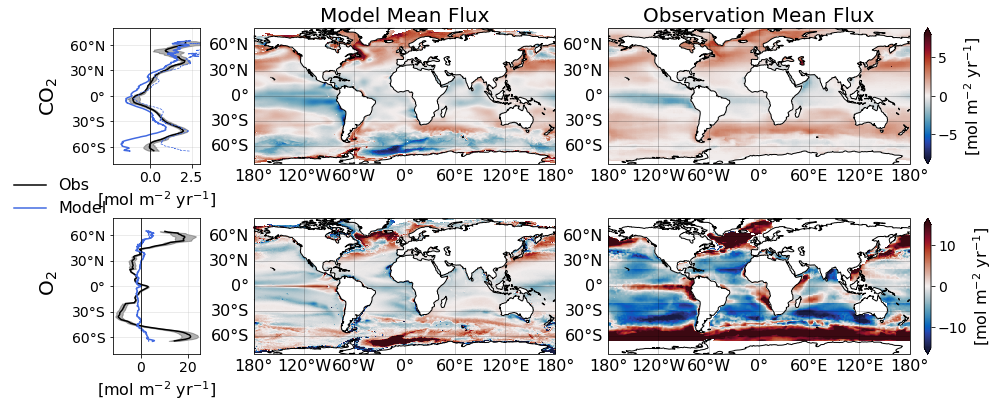

In [9]:

dic_zonal=ds.dic_stf_mean.mean(dim='xt_ocean')
o2_zonal=ds.o2_stf_mean.mean(dim='xt_ocean')
dic_zonal_cc=ds_cc.dic_stf_mean.mean(dim='xt_ocean')
o2_zonal_cc=ds_cc.o2_stf_mean.mean(dim='xt_ocean')


lat_true = ds.geolat_t.where(ds.geolat_t<=90).mean(dim='xt_ocean')
dic_zonal_new = dic_zonal.assign_coords(lat=lat_true)
o2_zonal_new = o2_zonal.assign_coords(lat=lat_true)
dic_zonal_new_cc = dic_zonal_cc.assign_coords(lat=lat_true)
o2_zonal_new_cc = o2_zonal_cc.assign_coords(lat=lat_true)


fig = plt.figure(figsize=(15,6), layout='compressed')

plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":20,
    "axes.labelsize":16,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 4, 4],   # small left column
    wspace=0.1,
    hspace=0.4
)

# --- Left column (zonal means) ---
ax_zm1 = fig.add_subplot(gs[0, 0])
ax_zm2 = fig.add_subplot(gs[1, 0])

# --- Maps ---
ax1 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree())

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([-180, 180, -81.108635, 81.108635],
                  crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1,
                      color='black',
                      alpha=0.2)
    gl.xlabels_top = False
    gl.ylabels_left = True
    gl.ylabels_right= False

    ax.coastlines()

# Row 1 (DIC flux)
im1 = ds.dic_stf_mean.plot(
    ax=ax1,
    x='geolon_t',
    y='geolat_t',
    vmin=-8, vmax=8,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

im2 = fay_all.plot(
    ax=ax2,
    vmin=-8, vmax=8,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# Row 2 (O2 flux)
im3 = ds.o2_stf_mean.plot(
    ax=ax3,
    x='geolon_t',
    y='geolat_t',
    vmin=-15, vmax=15,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
im4 =jin_all.plot(
    ax=ax4,
    vmin=-15, vmax=15,
    cmap=cmo.balance,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)

# --------------------------------------------------
# ZONAL MEANS
# --------------------------------------------------

# Compute zonal means (adjust dim names if needed)
fay_zm = fay_all.mean('lon')
jin_zm = jin_all.mean('lon')
fay_max_member=fay_all_.mean(dim='lon').max(dim=['wind', 'product'])
jin_max_member=jin_all_.mean(dim='lon').max(dim=['wind', 'method'])
fay_min_member=fay_all_.mean(dim='lon').min(dim=['wind', 'product'])
jin_min_member=jin_all_.mean(dim='lon').min(dim=['wind', 'method'])

fay_zm=fay_zm.where((fay_zm.lat<=65) & (fay_zm.lat >=-65))
jin_zm=jin_zm.where((jin_zm.lat<=65) & (jin_zm.lat >=-65))
fay_max_member=fay_max_member.where((fay_max_member.lat<=65) & (fay_max_member.lat >=-65))
jin_max_member=jin_max_member.where((jin_max_member.lat<=65) & (jin_max_member.lat >=-65))
fay_min_member=fay_min_member.where((fay_min_member.lat<=65) & (fay_min_member.lat >=-65))
jin_min_member=jin_min_member.where((jin_min_member.lat<=65) & (jin_min_member.lat >=-65))
dic_zonal_new=dic_zonal_new.where((dic_zonal_new.yt_ocean<=65) & (dic_zonal_new.yt_ocean >=-65))
o2_zonal_new=o2_zonal_new.where((o2_zonal_new.yt_ocean<=65) & (o2_zonal_new.yt_ocean >=-65))
dic_zonal_new_cc=dic_zonal_new_cc.where((dic_zonal_new_cc.yt_ocean<=65) & (dic_zonal_new_cc.yt_ocean >=-65))
o2_zonal_new_cc=o2_zonal_new_cc.where((o2_zonal_new_cc.yt_ocean<=65) & (o2_zonal_new_cc.yt_ocean >=-65))

# Plot zonal means

ax_zm1.plot(fay_zm, fay_zm.lat, c='k')
ax_zm1.fill_betweenx(fay_zm.lat,
                 fay_min_member,
                 fay_max_member,
                 alpha=0.3, color='k')

ax_zm2.plot(jin_zm, jin_zm.lat, c='k', label='Obs')
ax_zm2.fill_betweenx(jin_zm.lat,
                 jin_min_member,
                 jin_max_member,
                 alpha=0.3, color='k')

ax_zm1.plot(dic_zonal_new, dic_zonal_new.yt_ocean, c='royalblue')

ax_zm2.plot(o2_zonal_new, o2_zonal_new.yt_ocean, c='royalblue', label='Model')

ax_zm1.plot(dic_zonal_new_cc, dic_zonal_new_cc.yt_ocean, c='royalblue', linestyle='dashed', linewidth=0.7)

ax_zm2.plot(o2_zonal_new_cc, o2_zonal_new_cc.yt_ocean, c='royalblue', linestyle='dashed', linewidth=0.7)



# Formatting zonal panels
ticks = [0, 30, 60, -30, -60]  # latitudes
labels = ['0°', '30°N', '60°N', '30°S', '60°S']

for ax in [ax_zm1, ax_zm2]:
    ax.set_ylim(-80, 80)
    ax.axvline(0, color='k', linewidth=0.8)
    ax.grid(alpha=0.3)
    
    ax.set_yticks(ticks)
    ax.set_yticklabels(labels)

ax_zm1.set_xlim(-2.3, 3)
ax_zm2.set_xlim(-12, 25)

ax_zm1.set_title(" ")
ax_zm2.set_title(" ")

ax_zm1.set_ylabel("CO$_2$", fontsize=20,labelpad=10)
ax_zm2.set_ylabel(" O$_2$", fontsize=20,labelpad=10)

ax_zm1.set_xlabel("[mol m$^{-2}$ yr$^{-1}$]")
ax_zm2.set_xlabel("[mol m$^{-2}$ yr$^{-1}$]")

# Optional: match x-limits to color range
#ax_zm1.set_xlim(-15, 15)
#ax_zm2.set_xlim(-8, 8)


axs=[ax1, ax2, ax3, ax4]

####ADD Colorbars
cbar1 = fig.colorbar(
    im1,
    ax=[ax1, ax2],
    orientation='vertical',
    fraction=0.035,
    pad=0.02, extend='both'
)
cbar1.set_label('[mol m$^{-2}$ yr$^{-1}$]')

# --- Colorbar for second row (ax3, ax4) ---
cbar2 = fig.colorbar(
    im3,
    ax=[ax3, ax4],
    orientation='vertical',
    fraction=0.035,
    pad=0.02, extend='both'
)
cbar2.set_label('[mol m$^{-2}$ yr$^{-1}$]')
###titles

ax1.set_title('Model Mean Flux')
ax2.set_title('Observation Mean Flux')
ax3.set_title('')
ax4.set_title('')
ax_zm2.legend(loc='upper left', bbox_to_anchor=(-1.3, 1.4), frameon=False);
plt.savefig(pathp+'Model_Evaluation_3.png', dpi=300, bbox_inches='tight');